### Импорт и загрузка

In [3]:
import json
import matplotlib.pyplot as plt

sessions = []
with open("sessions.jsonl") as f:
    for line in f:
        line = line.strip()
        if line:
            sessions.append(json.loads(line))

print(f"Всего сессий: {len(sessions)}")
print(f"Первая сессия: {sessions[0]}")

Всего сессий: 2565
Первая сессия: [380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341, 293]


### Вспомогательные функции

In [4]:
def train_test_split(
    sessions: list[list[int]],
) -> tuple[list[list[int]], list[int]]:
    train_sessions = [session[:-1] for session in sessions]
    test_targets = [session[-1] for session in sessions]
    return train_sessions, test_targets


def hit_at_k(
    recommendations: list[list[int]],
    true_items: list[int],
    k: int = 10,
) -> float:
    assert len(recommendations) == len(true_items), \
        "recommendations и true_items должны совпадать по длине"
    hits = 0
    for recs, true_item in zip(recommendations, true_items):
        if true_item in recs[:k]:
            hits += 1
    return hits / len(true_items)

### Анализ данных и статистика

In [19]:
# Длины сессий
session_lengths = []
for session in sessions:
    session_lengths.append(len(session))

# Частота каждого товара
item_counts = {}
for session in sessions:
    for item in session:
        if item not in item_counts:
            item_counts[item] = 0
        item_counts[item] += 1

sorted_items = sorted(item_counts, key=lambda x: item_counts[x], reverse=True)

rare_1 = 0
rare_4 = 0
rare_5 = 0
rare_10 = 0
for item in item_counts:
    if item_counts[item] == 1:
        rare_1 += 1
    if item_counts[item] <= 4:
        rare_4 += 1
    if item_counts[item] <= 5:
        rare_5 += 1
    if item_counts[item] <= 10:
        rare_10 += 1

# Сколько сессий содержат повторяющиеся товары
sessions_with_repeats = 0
for session in sessions:
    if len(session) != len(set(session)):
        sessions_with_repeats += 1

total_views = 0
for item in item_counts:
    total_views += item_counts[item]

avg_length = sum(session_lengths) / len(session_lengths)

print("\n--- Анализ данных ---")
print(f"Число сессий:                 {len(sessions)}")
print(f"Число уникальных товаров:     {len(item_counts)}")
print(f"Всего просмотров:             {total_views}")
print(f"Средняя длина сессии:         {avg_length:.1f}")
print(f"Мин / Макс длина:             {min(session_lengths)} / {max(session_lengths)}")
print(f"Топ-5 товаров:                {sorted_items[:5]}")
print(f"Товаров встреч. 1 раз:        {rare_1} ({rare_1/len(item_counts)*100:.1f}%)")
print(f"Товаров встреч. <= 4 раз:     {rare_4} ({rare_4/len(item_counts)*100:.1f}%)")
print(f"Товаров встреч. <= 5 раз:     {rare_5} ({rare_5/len(item_counts)*100:.1f}%)")
print(f"Товаров встреч. <= 10 раз:     {rare_10} ({rare_10/len(item_counts)*100:.1f}%)")
print(f"Сессий с повторами товаров:   {sessions_with_repeats} ({sessions_with_repeats/len(sessions)*100:.1f}%)")


--- Анализ данных ---
Число сессий:                 2565
Число уникальных товаров:     400
Всего просмотров:             26843
Средняя длина сессии:         10.5
Мин / Макс длина:             3 / 20
Топ-5 товаров:                [54, 335, 53, 114, 260]
Товаров встреч. 1 раз:        0 (0.0%)
Товаров встреч. <= 4 раз:     0 (0.0%)
Товаров встреч. <= 5 раз:     2 (0.5%)
Товаров встреч. <= 10 раз:     29 (7.2%)
Сессий с повторами товаров:   1552 (60.5%)


### Визуализация

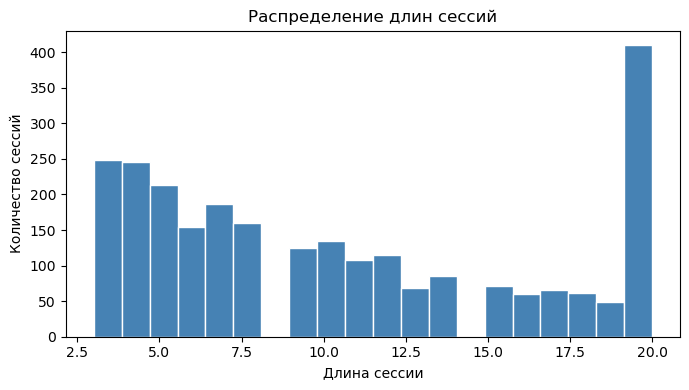

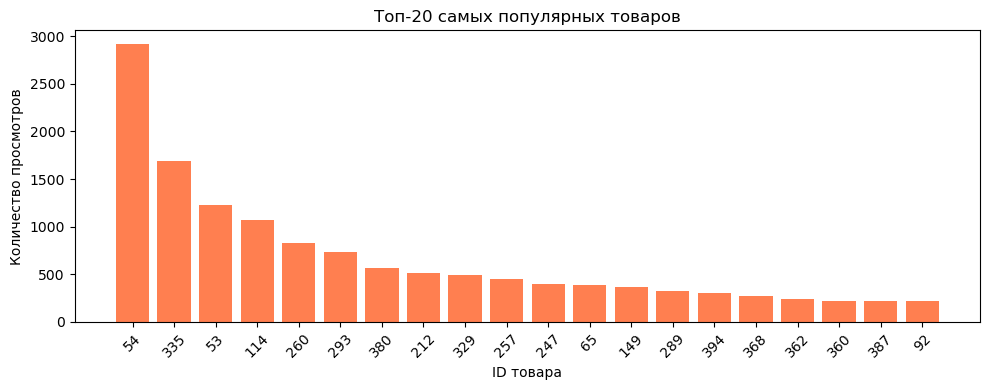

In [18]:
#график
plt.figure(figsize=(7, 4))
plt.hist(session_lengths, bins=20, color="steelblue", edgecolor="white")
plt.title("Распределение длин сессий")
plt.xlabel("Длина сессии")
plt.ylabel("Количество сессий")
plt.tight_layout()
plt.savefig("analysis.png", dpi=150)
plt.show()
plt.figure(figsize=(10, 4))
top_20_items = sorted_items[:20]
top_20_counts = [item_counts[item] for item in top_20_items]
plt.bar(range(20), top_20_counts, color='coral')
plt.xticks(range(20), [str(item) for item in top_20_items], rotation=45)
plt.title('Топ-20 самых популярных товаров')
plt.xlabel('ID товара')
plt.ylabel('Количество просмотров')
plt.tight_layout()
plt.show()

### Построение графа переходов и глобальный топ

In [50]:
#граф переходов
train_sessions, test_targets = train_test_split(sessions)
transitions = {}

for history in train_sessions:
    for pos in range(len(history) - 1):
        current   = history[pos]
        next_item = history[pos + 1]

        if current not in transitions:
            transitions[current] = {}
        if next_item not in transitions[current]:
            transitions[current][next_item] = 0
        transitions[current][next_item] += 1

print(f"\nТоваров в графе: {len(transitions)}")

# Глобальный топ
train_item_counts = {}
for history in train_sessions:
    for item in history:
        if item not in train_item_counts:
            train_item_counts[item] = 0
        train_item_counts[item] += 1

sorted_train_items = sorted(train_item_counts, key=lambda x: train_item_counts[x], reverse=True)
global_popular = sorted_train_items[:100]
# Считаем, сколько товаров встречаются реже порога
rare_count = 0
RARE_THRESHOLD = 18
for count in train_item_counts.values():
    if count < RARE_THRESHOLD:
        rare_count += 1
print(f"Товаров встречается < {RARE_THRESHOLD} раз: {rare_count}")


Товаров в графе: 400
Товаров встречается < 18 раз: 153


### Рекомендательная модель

In [60]:
def recommend(history, top_k=10):
    if len(history) == 0:
        return global_popular[:top_k]

    last_item = history[-1]

    # Узнаём, сколько раз встречался последний товар
    if last_item in train_item_counts:
        item_freq = train_item_counts[last_item]
    else:
        item_freq = 0

    # Если товар редкий (< RARE_THRESHOLD) — не доверяем графу, берём популярные
    if item_freq < RARE_THRESHOLD:
        return global_popular[:top_k]

    # Обычный случай: используем граф переходов
    if last_item not in transitions:
        return global_popular[:top_k]

    next_items = transitions[last_item]
    sorted_next = sorted(next_items, key=lambda x: next_items[x], reverse=True)
    return sorted_next[:top_k]

### Оценка качества и вывод

In [61]:
#оценка качества
predictions = []
for history in train_sessions:
    predictions.append(recommend(history))

baseline_preds = []
for i in range(len(test_targets)):
    baseline_preds.append(global_popular[:10])

model_score    = hit_at_k(predictions,    test_targets)
baseline_score = hit_at_k(baseline_preds, test_targets)

print("\n--- Оценка качества ---")
print(f"Hit@10 (граф переходов):  {model_score:.4f}  ({model_score * 100:.1f}%)")
print(f"Hit@10 (бейзлайн топ-10): {baseline_score:.4f}  ({baseline_score * 100:.1f}%)")

if model_score > baseline_score:
    diff = (model_score - baseline_score) * 100
    print(f"Модель лучше бейзлайна на +{diff:.1f}")
else:
    print("Модель не превышает бейзлайн.")


--- Оценка качества ---
Hit@10 (граф переходов):  0.5131  (51.3%)
Hit@10 (бейзлайн топ-10): 0.3840  (38.4%)
Модель лучше бейзлайна на +12.9
